# MEDA Kaggle Evidence, Architecture and Critical Review

In [5]:
from pathlib import Path
import sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
OUTPUTS, MODELS = ROOT/'outputs', ROOT/'models'
sns.set_theme(style='whitegrid')

evidence=pd.read_csv(OUTPUTS/'kaggle_evidence.csv'); display(evidence)

,file,model,local_mse,created_utc,sha256,kaggle_description,public_score,final_selected,evidence
0,submission_01_median.csv,median_baseline,43.171436,2026-07-29,d6a422c6ad5d478d4cdd22e624b381178eab4bcb584f40...,Median baseline,7049.045257,False,outputs/evidence/kaggle_submissions.png
1,submission_02_xgboost.csv,xgboost,11.998533,2026-07-29,3e9bff8d272bd1e8c6debe6330a18981756eac898dcea5...,Untuned XGBoost,5470.251455,False,outputs/evidence/kaggle_submissions.png
2,submission_03_selected.csv,xgboost_tuned,9.016493,2026-07-29,d01d528855a45cb6866793db065bfaba6b14565731496a...,Original validation-selected XGBoost,5458.353254,False,outputs/evidence/kaggle_submissions.png
3,submission_04_temporal_physics_residual.csv,physics_residual,4.774073,2026-07-29T10:24:26.028639+00:00,24aa771b8f9bfb6f77a9bed98638615dbed3ec2fc1a4c0...,Temporal physics-residual model; selected with...,NaN,False,Awaiting student upload/selection


## Kaggle evidence

Three model-generated submissions were accepted. Their public MSE values are 7049.045 (median), 5470.251 (untuned XGBoost) and 5458.353 (original selected XGBoost). The large difference from local scores is evidence of temporal distribution shift, not a reason to hide or optimise away the failure. The current screenshot shows that no final/private submission is selected; that checkbox and a new screenshot remain a student-owned manual action.

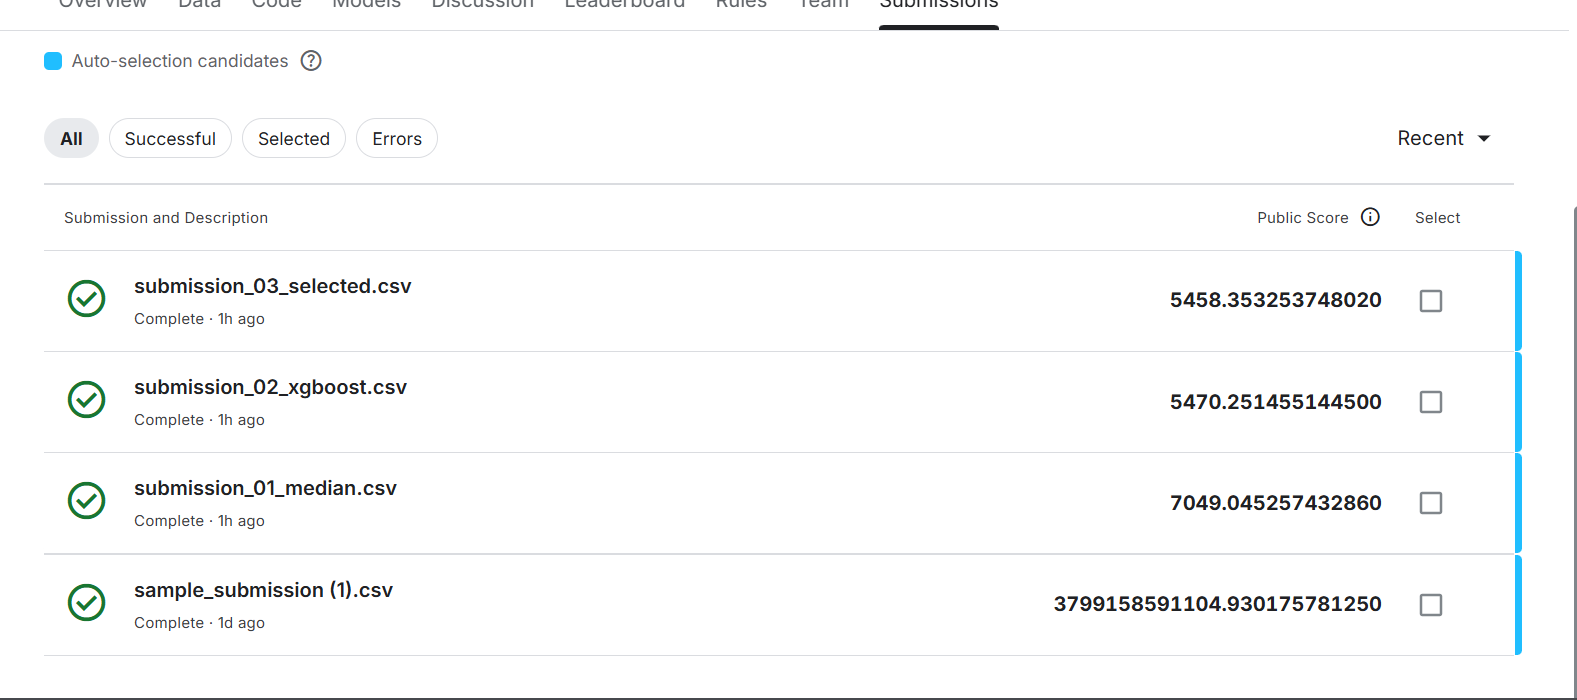

In [6]:
from IPython.display import Image, display
display(Image(filename=str(OUTPUTS/'evidence/kaggle_submissions.png')))

## Figure 1 - Kaggle submissions

**Finding.** All three candidate uploads completed successfully and the tuned candidate improved on the baseline, satisfying the multiple-submission requirement.

**Implication.** Hashes and filenames link leaderboard evidence to reproducible files.

**Limitation.** Public score is not a deployment guarantee, and the screenshot does not prove final/private selection.

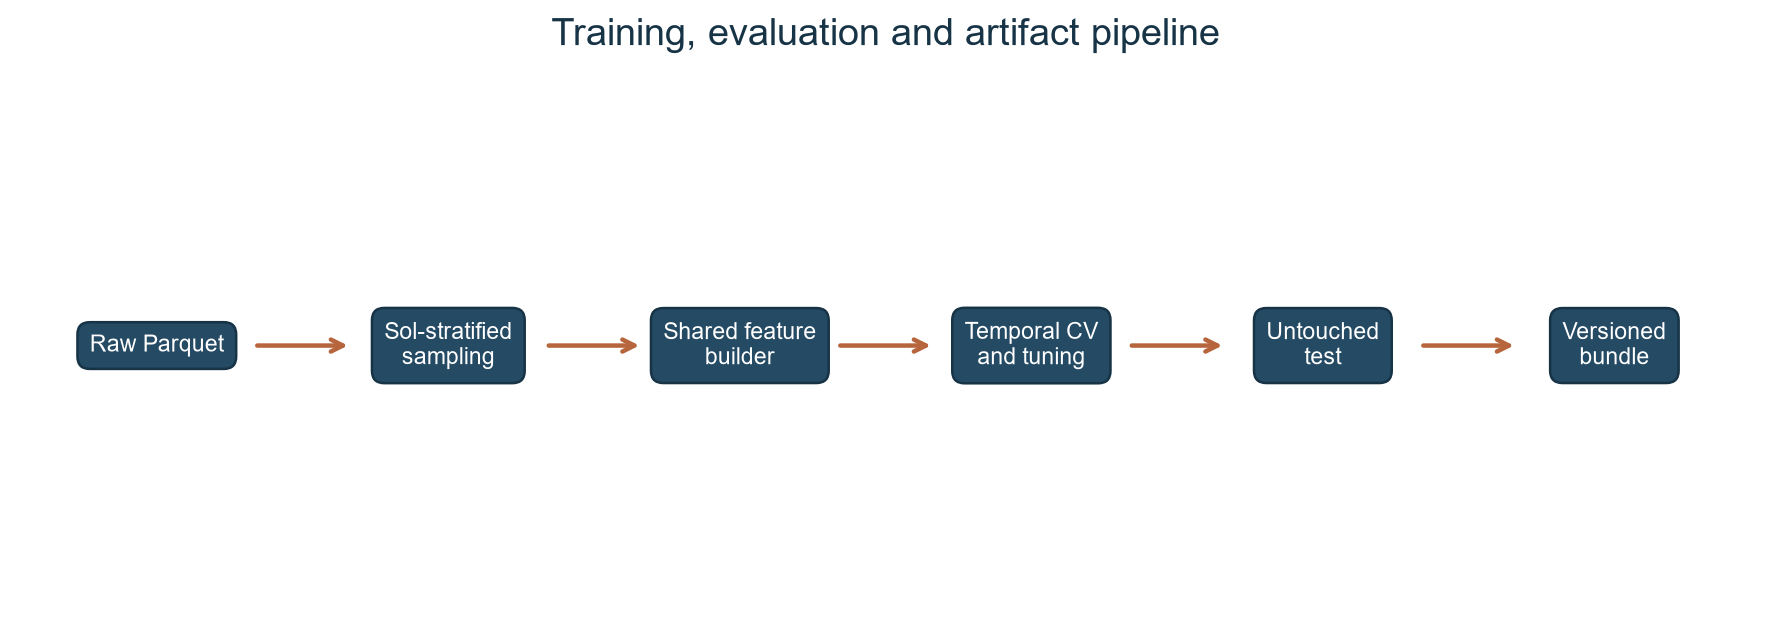

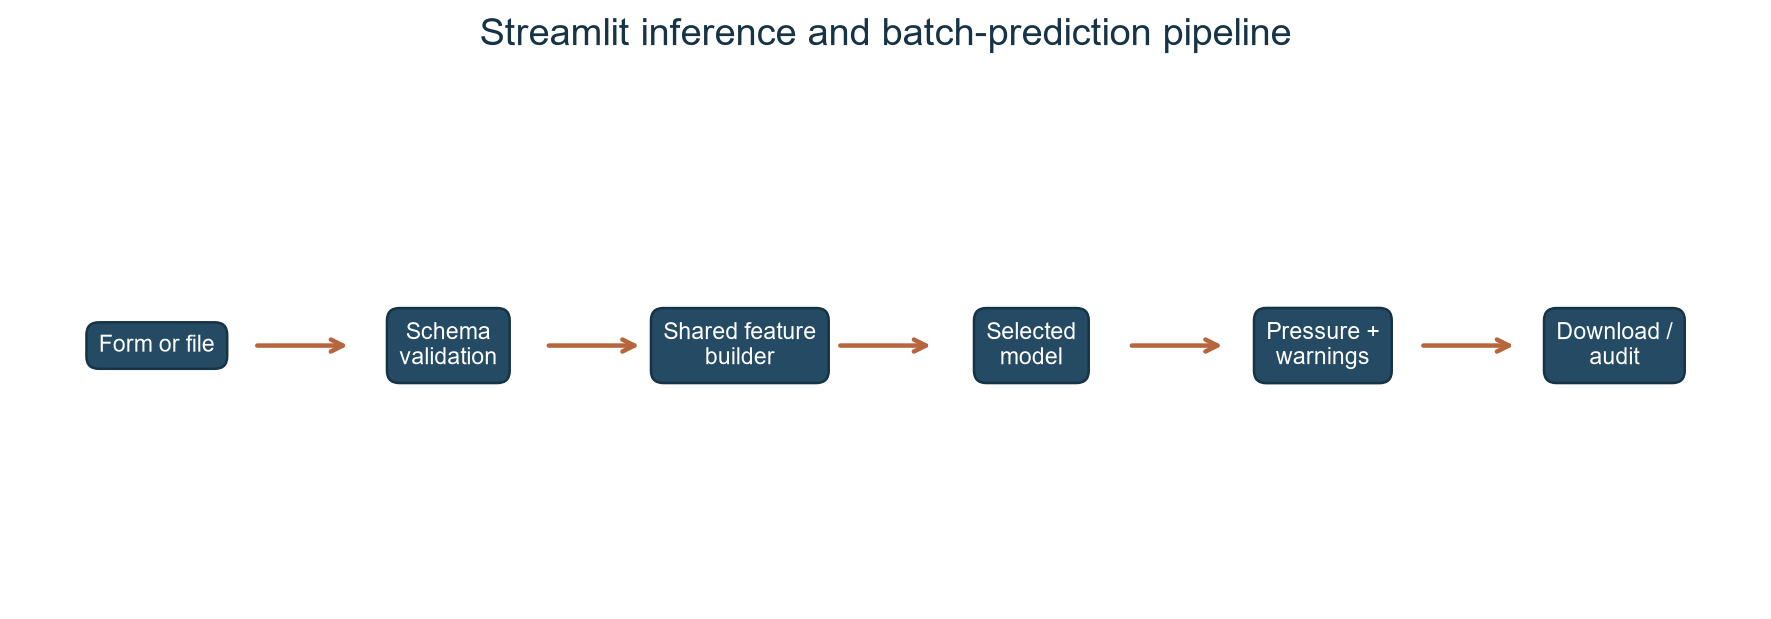

In [7]:
display(Image(filename=str(OUTPUTS/'figures/architecture_training.png'))); display(Image(filename=str(OUTPUTS/'figures/architecture_inference.png')))

## Architecture outcomes

The training architecture enforces a single preprocessing contract and keeps tuning separate from the untouched temporal test. Its main trade-off is that streaming and bounded training reduce memory demand but take longer and do not exploit every observation. The inference architecture accepts a form or raw file, validates schema, applies identical transformations, loads a versioned bundle and returns pressure plus warnings. This improves reproducibility over notebook-only prediction, but operational reliability still depends on monitoring seasonal range and sensor availability.

## Critical evaluation

The original pipeline appeared strong locally but sampled only early sols and reused validation information during tuning. The public failure exposes tree ensembles' poor extrapolation outside observed seasonal ranges. The rebuild adds complete sol coverage, cyclic physical representations, rolling validation and explicit limitations. XGBoost and CatBoost remain effective nonlinear tabular learners, while harmonic Ridge provides extrapolative structure and interpretability. The MLP is retained as required deep-learning evidence, but its higher compute demand, sensitivity to scaling/missingness and weak bounded-sample performance do not justify deployment. Sequence models could become suitable with continuous multi-sol windows and greater compute, especially if combined with physical constraints and uncertainty estimates.

Ethically, the app identifies itself as educational and not flight-qualified. Reproducibility is supported by seeds, hashes, trial histories and bundle metadata. Remaining risks include sampling bias, non-random instrument missingness, out-of-range use, unquantified predictive uncertainty and dependence on competition data definitions.

## Literature review hand-off

The report compares MEDA instrument and pressure studies with recent virtual-sensor, missing-data recovery, environmental forecasting and physics-informed ML research. It uses Harvard citations and distinguishes physical evidence from inferences made by this implementation.